### Import and reading

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [3]:
m = cv.imread('m.png', cv.IMREAD_GRAYSCALE)
m_binary = (m > 100).astype(np.uint8) 
cat_grayscale = cv.imread('cat_grayscale.jpg', cv.IMREAD_GRAYSCALE)
cat_color = cv.imread('cat_color.jpg', cv.IMREAD_COLOR_RGB)

### image values and sizes

In [4]:
m

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(630, 736), dtype=uint8)

In [5]:
np.unique(m)

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [6]:
m.shape

(630, 736)

In [7]:
cat_grayscale

array([[114, 114, 112, ..., 161, 159, 159],
       [114, 116, 116, ..., 165, 164, 166],
       [110, 113, 116, ..., 163, 164, 167],
       ...,
       [ 61,  64,  63, ..., 212, 213, 213],
       [ 61,  65,  64, ..., 214, 214, 215],
       [ 62,  67,  66, ..., 215, 216, 216]],
      shape=(933, 1400), dtype=uint8)

In [8]:
cat_grayscale.shape

(933, 1400)

In [9]:
cat_color

array([[[119, 109, 117],
        [119, 109, 117],
        [117, 110, 117],
        ...,
        [163, 164, 159],
        [162, 161, 159],
        [161, 160, 158]],

       [[119, 112, 119],
        [120, 113, 120],
        [120, 113, 120],
        ...,
        [164, 165, 160],
        [165, 164, 162],
        [164, 163, 161]],

       [[114, 109, 115],
        [116, 111, 117],
        [117, 112, 119],
        ...,
        [166, 165, 161],
        [166, 165, 161],
        [166, 165, 161]],

       ...,

       [[ 58,  63,  66],
        [ 59,  67,  69],
        [ 57,  66,  65],
        ...,
        [210, 214, 213],
        [213, 215, 212],
        [214, 216, 213]],

       [[ 60,  65,  68],
        [ 63,  68,  71],
        [ 60,  66,  66],
        ...,
        [212, 216, 215],
        [215, 217, 214],
        [216, 218, 215]],

       [[ 62,  66,  69],
        [ 66,  70,  73],
        [ 64,  68,  69],
        ...,
        [212, 216, 215],
        [215, 217, 214],
        [216, 218, 215]]

In [10]:
cat_color.shape

(933, 1400, 3)

### Histogram

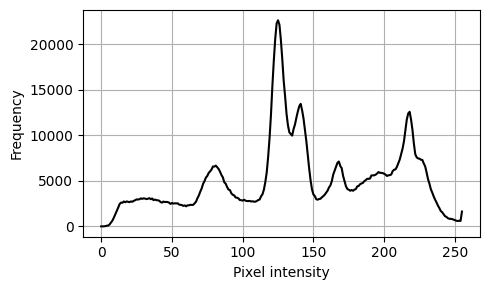

In [11]:
hist = cv.calcHist([cat_grayscale], [0], None, [256], [0, 256])

plt.figure(figsize=(5, 3))
plt.plot(hist, color='black')
plt.xlabel('Pixel intensity')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

### creating an image

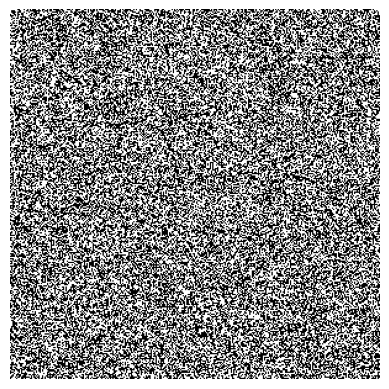

In [12]:
new_image = np.random.randint(0, 2, (300, 300))
plt.imshow(new_image, cmap='gray')
plt.axis('off')
plt.show()

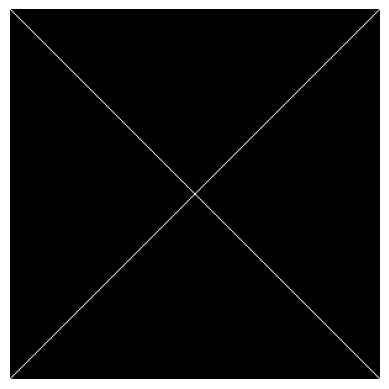

In [13]:
new_image1 = np.zeros((300, 300))
for i in range(300):
    new_image1[i, i] = 1
    new_image1[i, 299-i] = 1
plt.imshow(new_image1, cmap='gray')
plt.axis('off')
plt.savefig("fake.png")
plt.show()

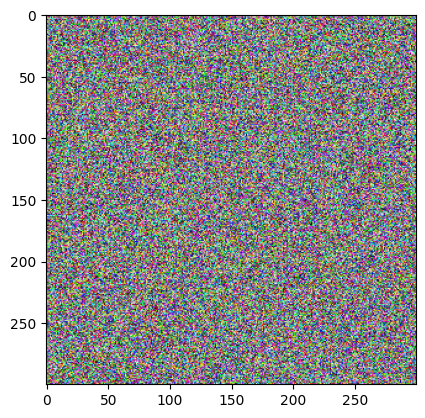

In [14]:
rgb_img = np.random.randint(0, 256, (300, 300, 3))
plt.imshow(rgb_img)

### morphological operations

In [ ]:
# Better kernel — 
better_kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))
erosion  = cv.erode(m_binary,  better_kernel, iterations=1)
dilation = cv.dilate(m_binary, better_kernel, iterations=1)
opening  = cv.morphologyEx(m_binary, cv.MORPH_OPEN,  better_kernel)
closing  = cv.morphologyEx(m_binary, cv.MORPH_CLOSE, better_kernel)

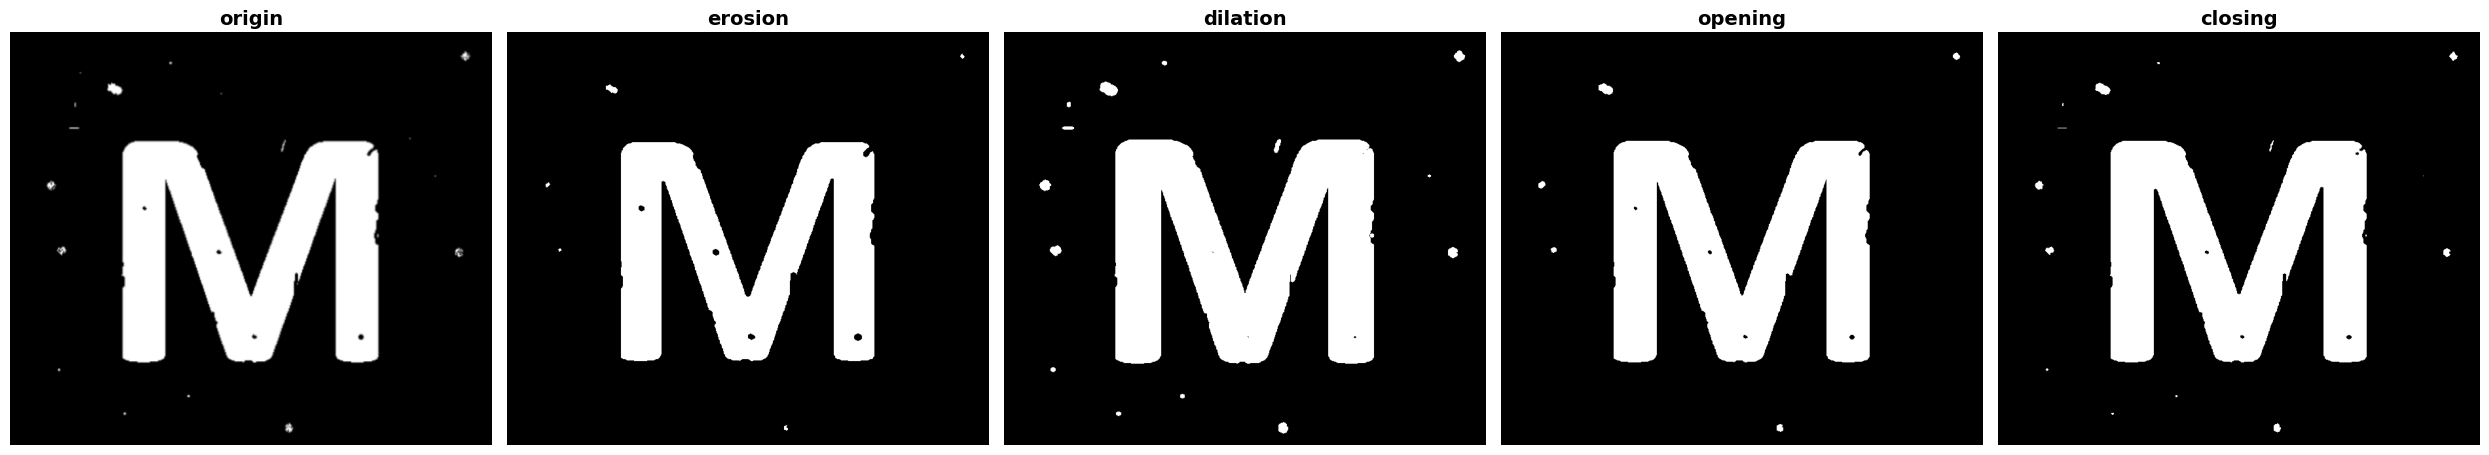

In [20]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
titles = ["origin", "erosion", "dilation", "opening", "closing"]
images = [m, erosion, dilation, opening, closing]

for i, ax in enumerate(axes):
    ax.imshow(images[i], cmap='gray')
    ax.axis('off')
    ax.set_title(titles[i], fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [41]:
plt.savefig('morphological_results.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

### Exercise

1. Choose a kernel that can offer better results

In [26]:
# code
better_kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (7, 7))

erosion  = cv.erode(m_binary, better_kernel, iterations=2)
dilation = cv.dilate(m_binary, better_kernel, iterations=2)
opening  = cv.morphologyEx(m_binary, cv.MORPH_OPEN,  better_kernel)
closing  = cv.morphologyEx(m_binary, cv.MORPH_CLOSE, better_kernel)

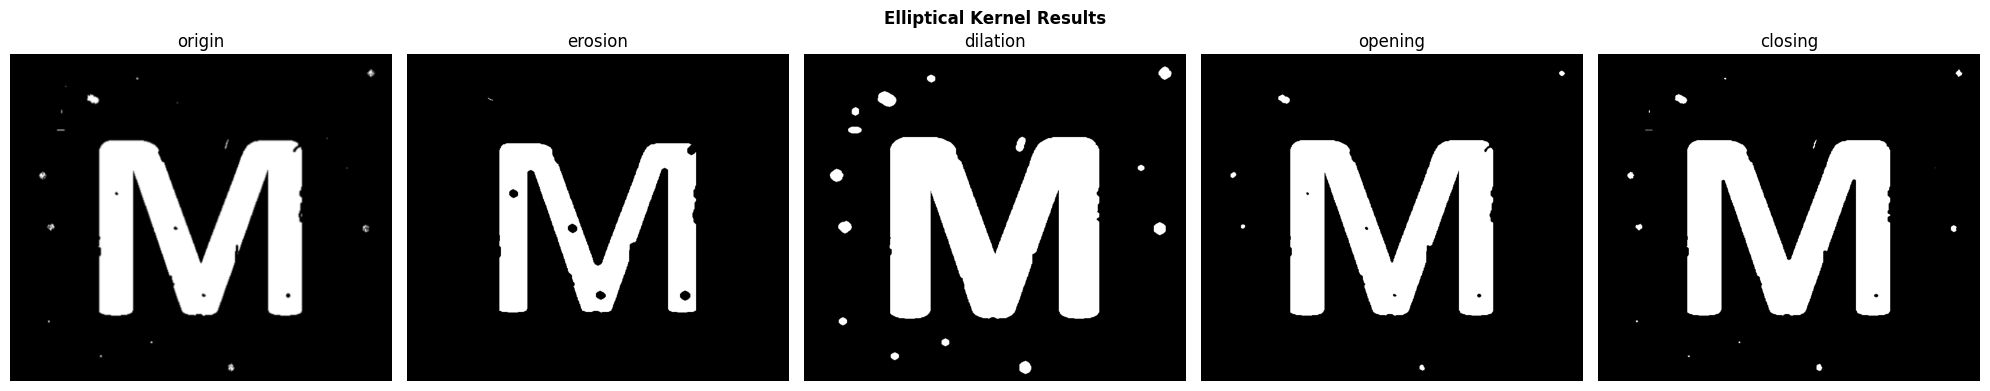

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
titles = ["origin", "erosion", "dilation", "opening", "closing"]
images = [m, erosion, dilation, opening, closing]
for i, ax in enumerate(axes):
    ax.imshow(images[i], cmap='gray')
    ax.axis('off')
    ax.set_title(titles[i])
plt.suptitle('Elliptical Kernel Results', fontweight='bold')
plt.tight_layout()
plt.show()

2. Create and show a binary image that displays your firstname (white for foreground and black for background)

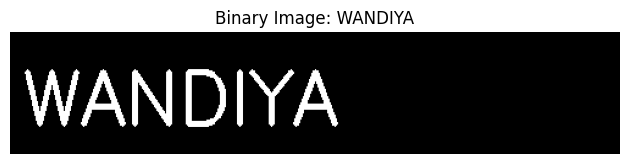

In [29]:
# code
# Exercise 2 — Binary image of WANDIYA
name_img = np.zeros((100, 500), dtype=np.uint8)  # black background

cv.putText(name_img,
           "WANDIYA",
           (10, 75),
           cv.FONT_HERSHEY_SIMPLEX,
           2,
           255,    # white foreground
           3)

plt.imshow(name_img, cmap='gray')
plt.axis('off')
plt.title('Binary Image: WANDIYA')
plt.tight_layout()
plt.show()


3. Add noise on your created binary image (white dots on the background and black holes on the foreground)

In [30]:
# code
# Exercise 3 — To add noise to binary image
noisy_img = name_img.copy()

In [31]:
# The White dots on black background
for _ in range(800):
    x = np.random.randint(0, noisy_img.shape[1])
    y = np.random.randint(0, noisy_img.shape[0])
    noisy_img[y, x] = 255

In [32]:
# The black holes on white foreground
for _ in range(500):
    x = np.random.randint(0, noisy_img.shape[1])
    y = np.random.randint(0, noisy_img.shape[0])
    noisy_img[y, x] = 0

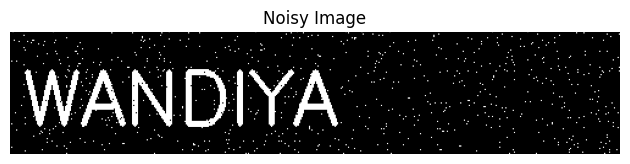

In [34]:
plt.imshow(noisy_img, cmap='gray')
plt.axis('off')
plt.title('Noisy Image')
plt.tight_layout()
plt.show()

4. Apply an appropriate morphological operation to clean up your noised image.

In [ ]:
# code
# Exercise 4 — Here, I want to clean up noisy image
clean_kernel = cv.getStructuringElement(cv.MORPH_RECT, (3, 3))
cleaned = cv.morphologyEx(noisy_img, cv.MORPH_OPEN, clean_kernel)
cleaned = cv.morphologyEx(cleaned, cv.MORPH_CLOSE, clean_kernel)

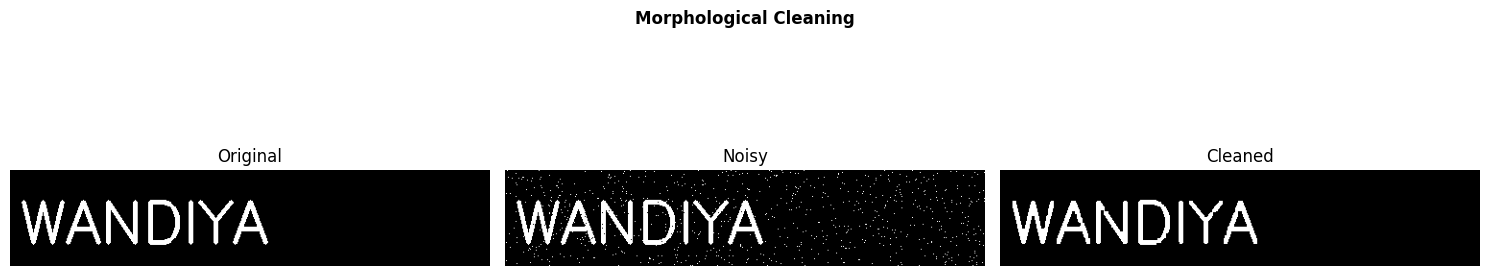

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(name_img,  cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(noisy_img, cmap='gray')
axes[1].set_title('Noisy')
axes[2].imshow(cleaned,   cmap='gray')
axes[2].set_title('Cleaned')
for ax in axes:
    ax.axis('off')
plt.suptitle('Morphological Cleaning', fontweight='bold')
plt.tight_layout()
plt.show()

5. Generate a color image that displays your first name, with each character shown in a different color.

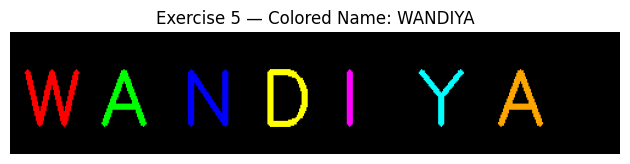

In [39]:
# code
# Exercise 5 — Colored WANDIYA
color_img = np.zeros((100, 500, 3), dtype=np.uint8)

name   = "WANDIYA"
colors = [
    (255, 0,   0),    # W — Red
    (0,   255, 0),    # A — Green
    (0,   0,   255),  # N — Blue
    (255, 255, 0),    # D — Yellow
    (255, 0,   255),  # I — Magenta
    (0,   255, 255),  # Y — Cyan
    (255, 165, 0),    # A — Orange
]

x_position = 10
for letter, color in zip(name, colors):
    cv.putText(color_img,
               letter,
               (x_position, 75),
               cv.FONT_HERSHEY_SIMPLEX,
               2,
               color,
               3)
    x_position += 65  # space between letters

plt.imshow(color_img)
plt.axis('off')
plt.title('Exercise 5 — Colored Name: WANDIYA')
plt.tight_layout()
plt.show()